In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [218]:
taxi_df = pd.read_csv(
    r"C:\Users\JYOTI_BEHERA\Downloads\2023_Yellow_Taxi_Trip_Data.csv",
    nrows=50000
)

In [167]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1,0.97,1,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1,1.10,1,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1,2.51,1,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0,1.90,1,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1,1.43,1,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [168]:
df.shape

(50000, 19)

In [169]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
airport_fee              float64
dtype: object

In [170]:
print(df.columns)

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [171]:
df['tpep_pickup_datetime'] = pd.to_datetime(
    df['tpep_pickup_datetime'],
    errors='coerce'
)

df['tpep_dropoff_datetime'] = pd.to_datetime(
    df['tpep_dropoff_datetime'],
    errors='coerce'
)

In [172]:
df['duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
)

df['duration'] = df['duration'].dt.total_seconds() / 60

In [173]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,duration
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1,0.97,1,N,161,141,2,9.3,1.00,0.5,0.00,0.00,1.0,14.30,2.5,0.00,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1,1.10,1,N,43,237,1,7.9,1.00,0.5,4.00,0.00,1.0,16.90,2.5,0.00,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1,2.51,1,N,48,238,1,14.9,1.00,0.5,15.00,0.00,1.0,34.90,2.5,0.00,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0,1.90,1,N,138,7,1,12.1,7.25,0.5,0.00,0.00,1.0,20.85,0.0,1.25,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1,1.43,1,N,107,79,1,11.4,1.00,0.5,3.28,0.00,1.0,19.68,2.5,0.00,10.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,2023-01-01 16:52:21,2023-01-01 17:19:11,2,1.10,1,N,48,230,3,17.0,2.50,0.5,0.00,0.00,1.0,21.00,2.5,0.00,26.833333
49996,2,2023-01-01 16:42:05,2023-01-01 17:04:13,1,5.57,1,N,138,202,1,26.8,5.00,0.5,4.00,0.00,1.0,38.55,0.0,1.25,22.133333
49997,2,2023-01-01 16:06:08,2023-01-01 16:51:32,2,17.71,2,N,132,246,1,70.0,0.00,0.5,16.36,6.55,1.0,98.16,2.5,1.25,45.400000
49998,2,2023-01-01 16:57:07,2023-01-01 17:36:01,1,19.88,2,N,132,263,1,70.0,0.00,0.5,16.36,6.55,1.0,98.16,2.5,1.25,38.900000


In [174]:
df=df[['passenger_count','payment_type','fare_amount','trip_distance','duration']]


In [175]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,2,9.3,0.97,8.433333
1,1,1,7.9,1.10,6.316667
2,1,1,14.9,2.51,12.750000
3,0,1,12.1,1.90,9.616667
4,1,1,11.4,1.43,10.833333
...,...,...,...,...,...
49995,2,3,17.0,1.10,26.833333
49996,1,1,26.8,5.57,22.133333
49997,2,1,70.0,17.71,45.400000
49998,1,1,70.0,19.88,38.900000


In [176]:
df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [177]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [178]:
df.describe()

,passenger_count,payment_type,fare_amount,trip_distance,duration
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.558020,1.295940,20.758384,4.051204,16.657653
std,1.030444,0.556099,20.446924,4.849081,58.795762
min,0.000000,1.000000,-346.000000,0.000000,0.000000
25%,1.000000,1.000000,9.300000,1.210000,6.733333
50%,1.000000,1.000000,14.200000,2.200000,11.533333
75%,2.000000,2.000000,24.700000,4.600000,18.916667
max,6.000000,4.000000,454.500000,105.550000,1439.016667


In [179]:
df['duration'].describe()

count    50000.000000
mean        16.657653
std         58.795762
min          0.000000
25%          6.733333
50%         11.533333
75%         18.916667
max       1439.016667
Name: duration, dtype: float64

In [180]:
df['fare_amount'].mean()

np.float64(20.758383600000002)

In [181]:
df[['trip_distance',
    'fare_amount',
    'duration']].corr()

,trip_distance,fare_amount,duration
trip_distance,1.000000,0.847716,0.149021
fare_amount,0.847716,1.000000,0.138478
duration,0.149021,0.138478,1.000000


In [182]:
df.dropna(inplace=True)
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,2,9.3,0.97,8.433333
1,1,1,7.9,1.10,6.316667
2,1,1,14.9,2.51,12.750000
3,0,1,12.1,1.90,9.616667
4,1,1,11.4,1.43,10.833333
...,...,...,...,...,...
49995,2,3,17.0,1.10,26.833333
49996,1,1,26.8,5.57,22.133333
49997,2,1,70.0,17.71,45.400000
49998,1,1,70.0,19.88,38.900000


In [183]:
df['passenger_count']=df['passenger_count'].astype('int64')
df['payment_type']=df['payment_type'].astype('int64')


In [184]:
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
1679,1,1,6.5,0.71,4.600000
2662,1,1,10.7,2.10,7.350000
2794,1,1,7.2,1.10,5.616667
3383,2,1,5.1,0.75,2.116667
3653,1,1,8.6,1.21,6.166667
...,...,...,...,...,...
49876,1,1,4.4,0.40,4.150000
49877,1,1,7.9,1.10,6.250000
49897,1,1,6.5,0.90,3.783333
49923,1,1,9.3,1.00,9.183333


In [185]:
df.drop_duplicates(inplace=True)

In [186]:
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.634219
2    0.214673
3    0.062994
4    0.040156
0    0.019456
5    0.018336
6    0.010166
Name: proportion, dtype: float64

In [187]:
df['payment_type'].value_counts(normalize=True)

payment_type
1    0.737858
2    0.240506
4    0.014485
3    0.007151
Name: proportion, dtype: float64

In [188]:
df = df[df['payment_type'] < 3]

df = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] < 6)
]

In [189]:
df.shape

(46608, 5)

In [190]:
df['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

In [191]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,46608.000000,46608.000000,46608.000000,46608.000000
mean,1.553982,21.384857,4.145682,17.018759
std,0.926206,19.938119,4.892313,59.961303
min,1.000000,-105.900000,0.000000,0.000000
25%,1.000000,9.300000,1.260000,6.950000
50%,1.000000,14.200000,2.280000,11.816667
75%,2.000000,25.400000,4.730000,19.250000
max,5.000000,454.500000,105.550000,1439.016667


In [192]:
df=df[df['fare_amount']>0]
df=df[df['trip_distance']>0]
df=df[df['duration']>0]

(array([4.1157e+04, 4.3090e+03, 2.4700e+02, 4.0000e+01, 1.0000e+01,
        7.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([2.0000e-01, 4.5630e+01, 9.1060e+01, 1.3649e+02, 1.8192e+02,
        2.2735e+02, 2.7278e+02, 3.1821e+02, 3.6364e+02, 4.0907e+02,
        4.5450e+02]),
 <BarContainer object of 10 artists>)

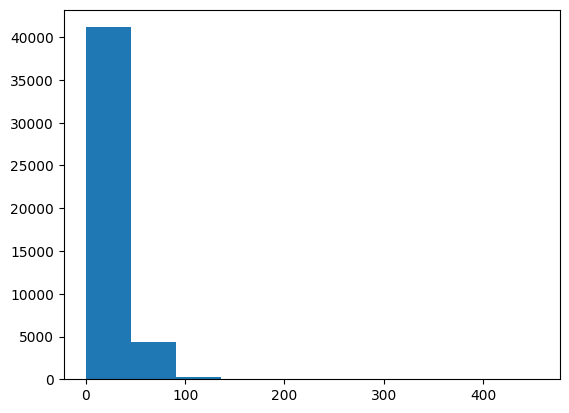

In [193]:
plt.hist(df['fare_amount'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1fe9c73a990>,
 'caps': [<matplotlib.lines.Line2D at 0x1fe9c73ac10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fe9c73a850>],
 'medians': [<matplotlib.lines.Line2D at 0x1fe9c73ae90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fe9c73afd0>],
 'means': []}

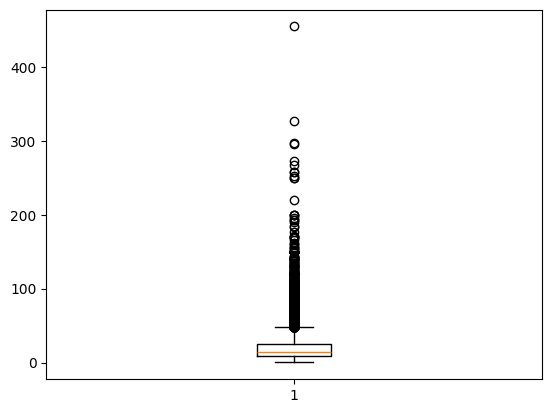

In [194]:
plt.boxplot(df['fare_amount'])

In [195]:
for col in ['fare_amount','trip_distance','duration']:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1

    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
    

In [196]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Cash,9.3,0.97,8.433333
1,1,Card,7.9,1.10,6.316667
2,1,Card,14.9,2.51,12.750000
4,1,Card,11.4,1.43,10.833333
5,1,Card,12.8,1.84,12.300000
...,...,...,...,...,...
49992,5,Card,8.6,0.74,7.233333
49993,1,Card,17.7,3.00,21.016667
49994,1,Card,5.1,0.30,4.216667
49996,1,Card,26.8,5.57,22.133333


In [197]:
df.shape

(37723, 5)

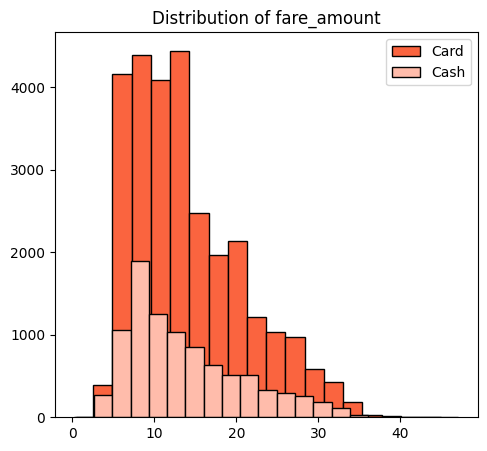

In [198]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of fare_amount')
plt.hist(df[df['payment_type']=='Card']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#FA643F',label='Card')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#FFBCAB',label='Cash')
plt.legend()
plt.show()

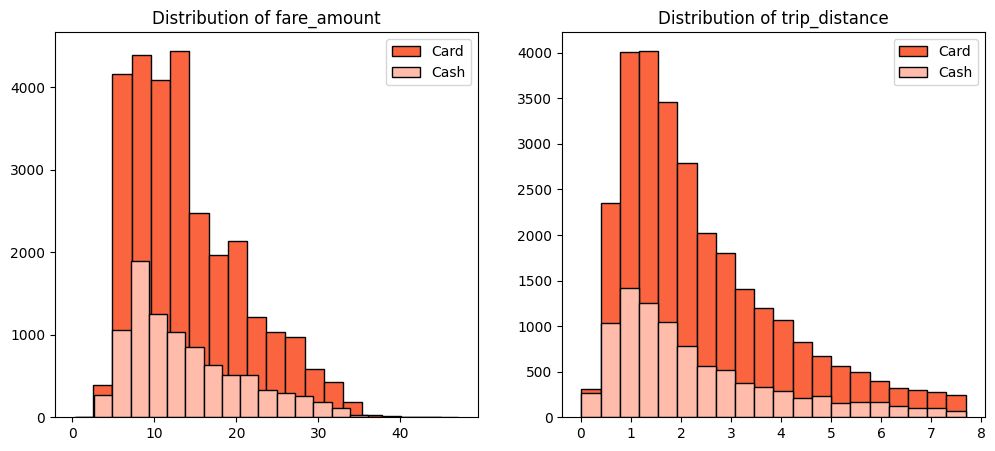

In [199]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of fare_amount')
plt.hist(df[df['payment_type']=='Card']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#FA643F',label='Card')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#FFBCAB',label='Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution of trip_distance')
plt.hist(df[df['payment_type']=='Card']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#FA643F',label='Card')
plt.hist(df[df['payment_type']=='Cash']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#FFBCAB',label='Cash')
plt.legend()
plt.show()

In [200]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           14.101683  6.831974      2.418949  1.616970
Cash           13.741277  7.045207      2.313427  1.702606

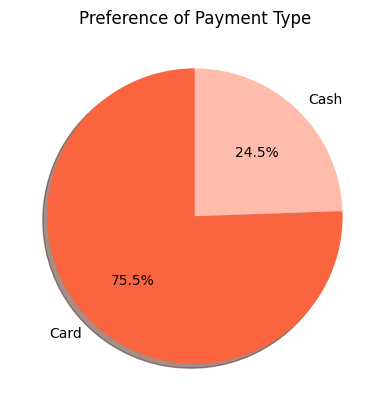

In [201]:
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize=True),labels=df['payment_type'].value_counts().index,
        startangle=90,shadow=True,autopct='%1.1f%%',colors=['#FA643F','#FFBCAB'])
plt.show()

In [202]:
passenger_count = df.groupby(
    ['payment_type', 'passenger_count']
)[['passenger_count']].count()

In [203]:
passenger_count.rename(
    columns={'passenger_count': 'count'},
    inplace=True
)

In [204]:
passenger_count.reset_index(inplace=True)

In [205]:
passenger_count.head()

,payment_type,passenger_count,count
0,Card,1,18891
1,Card,2,6338
2,Card,3,1739
3,Card,4,960
4,Card,5,571


In [206]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100

In [207]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,18891,50.078202
1,Card,2,6338,16.801421
2,Card,3,1739,4.609920
3,Card,4,960,2.544867
4,Card,5,571,1.513665
5,Cash,1,6138,16.271240
6,Cash,2,1847,4.896217
7,Cash,3,589,1.561382
8,Cash,4,464,1.230019
9,Cash,5,186,0.493068


In [208]:
df=pd.DataFrame(columns=['payment_type',1,2,3,4,5])
df['payment_type']=['Card','Cash']
df.iloc[0,1:]=passenger_count.iloc[0:5,-1]
df.iloc[1,1:]=passenger_count.iloc[5:,-1]
df

,payment_type,1,2,3,4,5
0,Card,50.078202,16.801421,4.60992,2.544867,1.513665
1,Cash,16.27124,4.896217,1.561382,1.230019,0.493068


<Axes: ylabel='payment_type'>

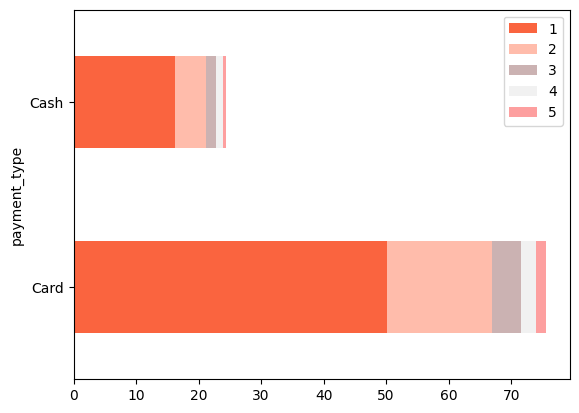

In [209]:
df.plot(x= 'payment_type',kind='barh',stacked=True,color=['#FA643F','#FFBCAB','#CBB2B2','#F1F1F1','#FD9F9F'])

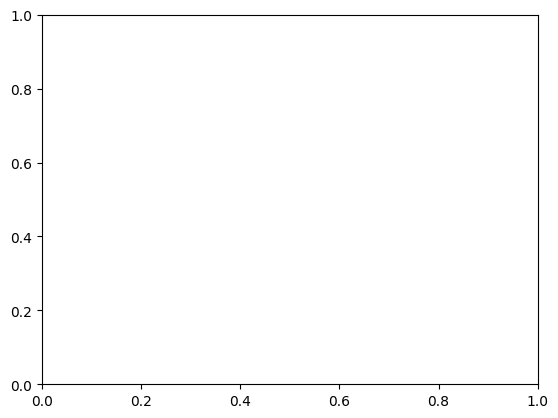

In [210]:
fig, ax = plt.subplots()

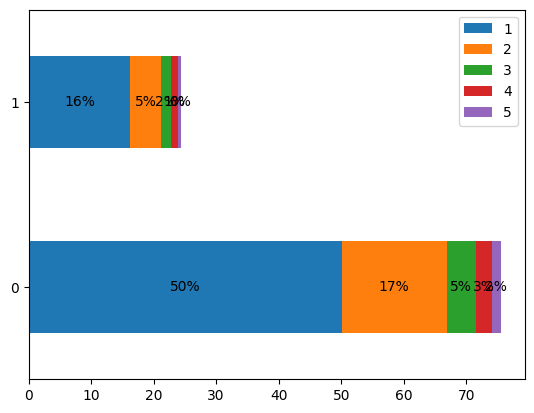

In [211]:
ax = df.plot(
    kind='barh',
    stacked=True
)

for p in ax.patches:

    width = p.get_width()
    height = p.get_height()

    x, y = p.get_xy()

    ax.text(
        x + width/2,
        y + height/2,
        '{:.0f}%'.format(width),
        ha='center',
        va='center'
    )

plt.show()

In [212]:
import statsmodels.api as sm

In [219]:
taxi_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [220]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

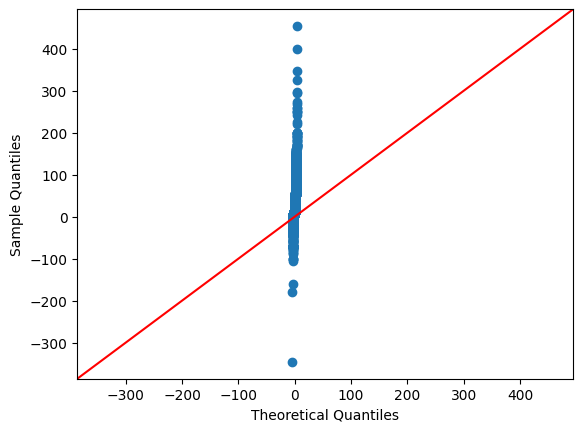

In [221]:
sm.qqplot(taxi_df['fare_amount'], line='45')
plt.show()

In [224]:
card_sample=df[df['payment_type']=='Card']
cash_sample=df[df['payment_type']=='Cash']

In [ ]:
t_stats,p_value=st.ttest_ind(a=card_sample,b=cash_sample,equal_var=False)
print('T statistic',t_stats,'p_value',p_value)
